[source](https://scicomp.stackexchange.com/questions/37336/solving-numerically-the-1d-kuramoto-sivashinsky-equation-using-spectral-methods)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

In [26]:
nu = 1
L = 100 
nx = 1024

t0 = 0 
tN = 200
dt = 0.05
nt = int((tN - t0) / 0.05)

# wave number mesh
k = np.arange(-nx/2, nx/2, 1)

t = np.linspace(start=t0, stop=tN, num=nt)
x = np.linspace(start=0, stop=L, num=nx)

# solution mesh in real space
u = np.ones((nx, nt))
# solution mesh in Fourier space
u_hat = np.ones((nx, nt), dtype=complex)

u_hat2 = np.ones((nx, nt), dtype=complex)

# initial condition 
u0 = np.cos((2 * np.pi * x) / L) + 0.1 * np.cos((4 * np.pi * x) / L)

# Fourier transform of initial condition
u0_hat = (1 / nx) * np.fft.fftshift(np.fft.fft(u0))

u0_hat2 = (1 / nx) * np.fft.fftshift(np.fft.fft(u0**2))

# set initial condition in real and Fourier mesh
u[:,0] = u0
u_hat[:,0] = u0_hat

u_hat2[:,0] = u0_hat2


In [27]:

# Fourier Transform of the linear operator
FL = (((2 * np.pi) / L) * k) ** 2 - nu * (((2 * np.pi) / L) * k) ** 4
# Fourier Transform of the non-linear operator
FN = - (1 / 2) * ((1j) * ((2 * np.pi) / L) * k)

# resolve EDP in Fourier space
for j in range(0,nt-1):
  uhat_current = u_hat[:,j]
  uhat_current2 = u_hat2[:,j]
  if j == 0:
    uhat_last = u_hat[:,0]
    uhat_last2 = u_hat2[:,0]
  else:
    uhat_last = u_hat[:,j-1]
    uhat_last2 = u_hat2[:,j-1]
  
  # compute solution in Fourier space through a finite difference method
  # Cranck-Nicholson + Adam 
  u_hat[:,j+1] = (1 / (1 - (dt / 2) * FL)) * ( (1 + (dt / 2) * FL) * uhat_current + ( ((3 / 2) * FN) * (uhat_current2) - ((1 / 2) * FN) * (uhat_last2) ) * dt )
  # go back in real space
  u[:,j+1] = np.real(nx * np.fft.ifft(np.fft.ifftshift(u_hat[:,j+1])))
  u_hat2[:,j+1] = (1 / nx) * np.fft.fftshift(np.fft.fft(u[:,j+1]**2))


Text(0.5, 1.0, 'Kuramoto-Sivashinsky: L = 100, nu = 1')

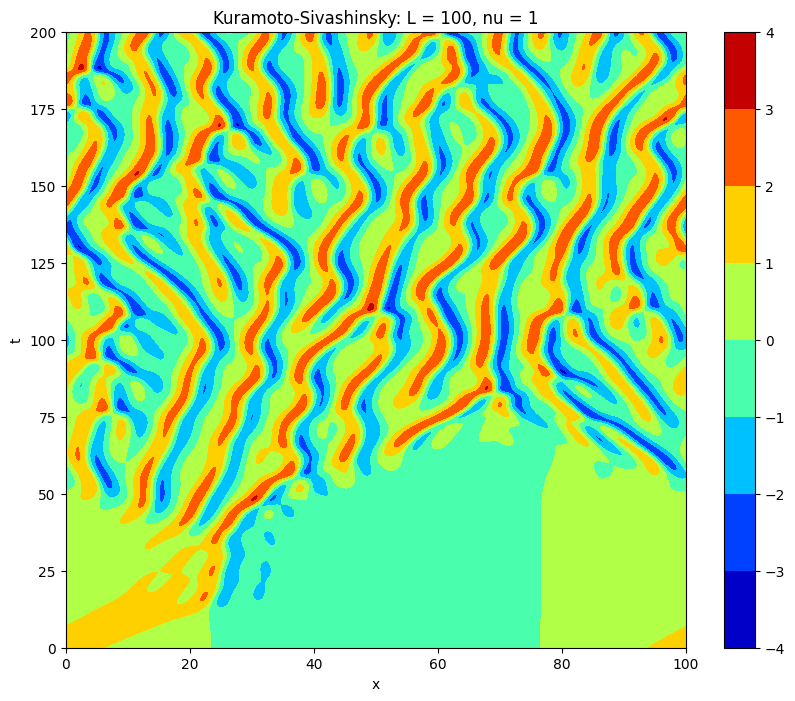

In [28]:
# plot the result
fig, ax = plt.subplots(figsize=(10,8))

xx, tt = np.meshgrid(x, t)
cs = ax.contourf(xx, tt, u.T, cmap=cm.jet)
fig.colorbar(cs)

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title(f"Kuramoto-Sivashinsky: L = {L}, nu = {nu}")

In [29]:
from IPython.display import clear_output
import time

def visualize(x, u, frame_skip=100, max_frames=20):
    n_time = u.shape[1]

    total_frames = min(n_time // frame_skip, max_frames)
    frames_to_show = np.linspace(0, n_time-1, total_frames, dtype=int)

    for frame in frames_to_show:
        clear_output(wait=True)

        plt.figure(figsize=(10, 6))
        plt.plot(x, u[:, frame], 'b-', linewidth=2)
        plt.xlabel('Position (x)')
        plt.ylabel('Amplitude (u)')
        plt.title(f'Frame {frame} ({(frame/(n_time-1)*100):.1f}%)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        time.sleep(0.5)


In [30]:
#visualize(x, u, 10, 200)

In [31]:
data = u.T

In [32]:
from pyshred import DataManager, SHRED, SHREDEngine

manager = DataManager(
    lags=500,
    train_size=0.5,
    val_size=0.1,
    test_size=0.4
)

In [33]:
manager.add_data(
    data=data,
    id="1dks",
    random=5,
    compress=30
)

In [34]:
train_dataset, val_dataset, test_dataset= manager.prepare()

In [35]:
Vt = manager._Vt_registry['1dks']
scaler = manager._preSVD_scaler_registry['1dks']
compressed_data = manager.data
X_true = data
Z = manager.data["1dks"] if isinstance(manager.data, dict) else manager.data
X_20 = scaler.inverse_transform(Z @ Vt)

err = X_true - X_20  # (time, space)
abs_err = np.abs(err)
abs_err.shape

(4000, 1024)

Basically, error between true and reconstructed modes depends on the time when chaos starts.

For example one can plot $nu=1$ and $nu=4$

Text(0.5, 1.0, 'Error between GT and first 30 modes')

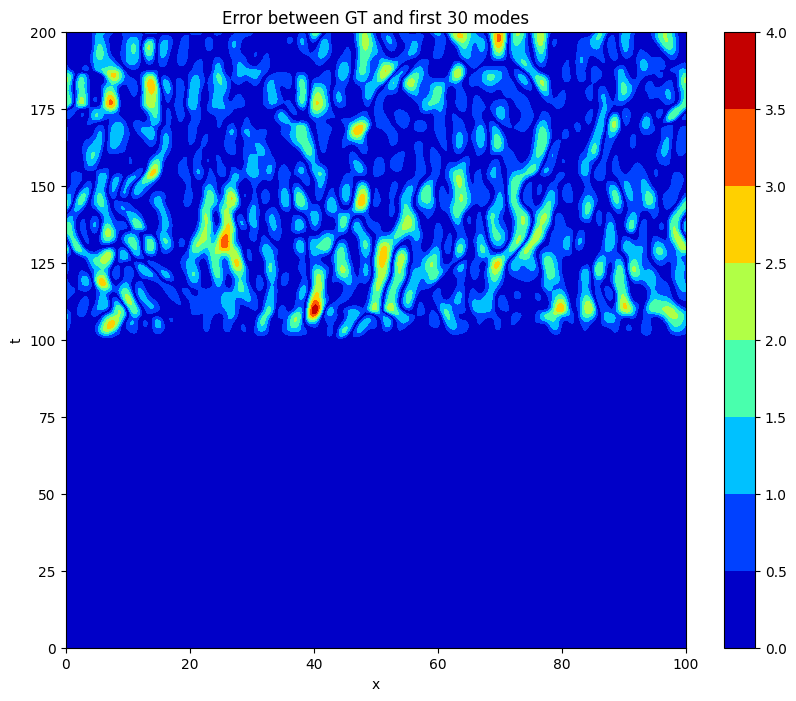

In [36]:
# plot the result
fig, ax = plt.subplots(figsize=(10,8))

xx, tt = np.meshgrid(x, t)
cs = ax.contourf(xx, tt, abs_err, cmap=cm.jet)
fig.colorbar(cs)

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title(f"Error between GT and first 30 modes")